<a href="https://colab.research.google.com/github/frfernandini/DL_evaluacion_2/blob/main/DL_evaluacion_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introducción: Descripción del problema y objetivo del modelo

Para este proyecto práctico, abordaremos un problema de clasificación de imágenes de prendas de vestir utilizando el reconocido dataset Fashion-MNIST.

El dataset está compuesto por 70.000 imágenes en escala de grises con una resolución estandarizada de 28x28 píxeles. Estas imágenes se dividen en 60.000 muestras para el entrenamiento del modelo y 10.000 muestras exclusivas para la prueba y validación. El objetivo predictivo cuenta con 10 categorías distintas , que incluyen prendas como camisetas, pantalones, suéteres, vestidos, abrigos y distintos tipos de calzado y accesorios.

el proyecto tiene como objetivo principal implementar una Red Neuronal Artificial del tipo CNN para la solución de este problema de clasificación multiclase.

#Carga de datos

In [2]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



(imgs_train,labs_train), (imgs_test,labs_test) = fashion_mnist.load_data()
print(imgs_train.shape)
print(imgs_test.shape)
nombres = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


En esta sección se inicializa el entorno de trabajo y se preparan los datos para la red neuronal:

Librerías: Se cargan tensorflow.keras, numpy, pandas y matplotlib. Estas son esenciales para construir el modelo, manipular arreglos numéricos y visualizar resultados.

Carga del Dataset: Se utiliza fashion_mnist.load_data() para obtener el conjunto de datos de entrenamiento (60,000 imágenes) y prueba (10,000 imágenes) de 28x28 píxeles.

Definición de Etiquetas: Se crea una lista llamada nombres que mapea los índices numéricos a categorías de ropa legibles (ej: 'Camiseta/Top', 'Bolso', 'Botín').

# Visualizacion

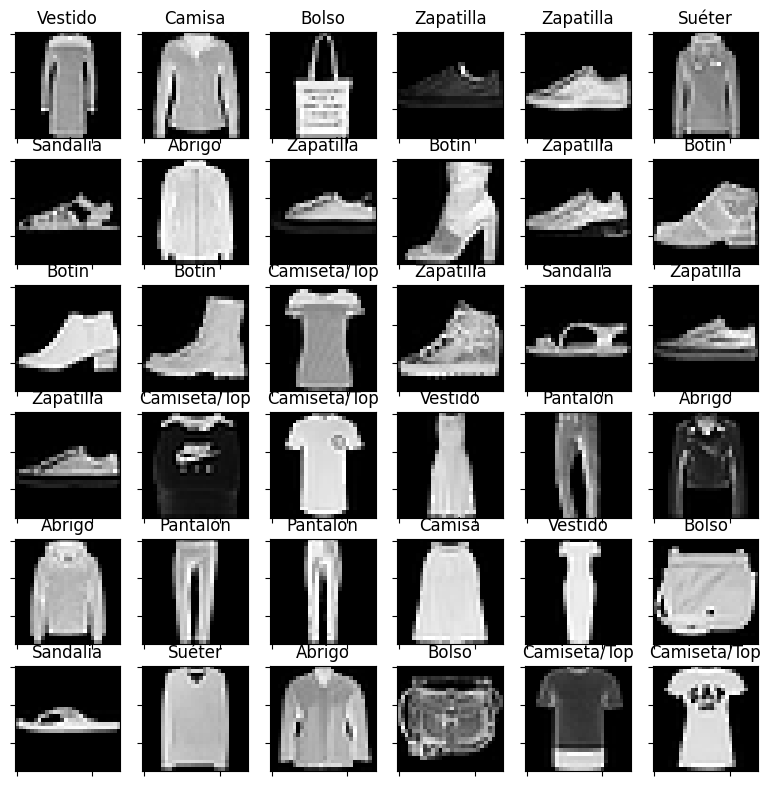

In [3]:
h = 6 # alto de la grilla
w = 6 # ancho de la grilla
fig, axs = plt.subplots(h, w, figsize=(1.6*h,1.6*w))
for i in range(h):
  for j in range(w):
    ex = np.random.randint(len(imgs_test))
    axs[i,j].set_title(nombres[labs_test[ex]])
    axs[i,j].grid(False)
    axs[i,j].set_xticklabels([])
    axs[i,j].set_yticklabels([])
    axs[i,j].imshow(imgs_test[ex], cmap='gray')

Aqui se crea una cuadrícula de 6x6 (36 imágenes) usando plt.subplots.

 Ademas, se utiliza np.random.randint para seleccionar imágenes al azar del set de prueba, mostrando la imagen en escala de grises (cmap='gray') y asignando su etiqueta correspondiente como título. Esto permite validar visualmente que los datos se cargaron correctamente.

#Validacion de datos

In [4]:
import numpy as np
print(f"\n1. Dimensiones:")
print(f"   Imágenes de entrenamiento: {imgs_train.shape} ({imgs_train.shape[0]} muestras de {imgs_train.shape[1]}x{imgs_train.shape[2]} píxeles)")
print(f"   Imágenes de prueba:        {imgs_test.shape} ({imgs_test.shape[0]} muestras de {imgs_test.shape[1]}x{imgs_test.shape[2]} píxeles)")
print(f"   Etiquetas de entrenamiento:{labs_train.shape}")
print(f"   Etiquetas de prueba:       {labs_test.shape}")

print(f"\n2. Búsqueda de valores nulos:")
nulos_train = np.isnan(imgs_train).sum()
nulos_test = np.isnan(imgs_test).sum()
if nulos_train == 0 and nulos_test == 0:
    print("Dataset limpio")
else:
    print(f"Se encontraron {nulos_train} nulos en train y {nulos_test} en test")


print(f"\n3. Rango de píxeles original (debe ser de 0 a 255):")
print(f"   Set Entrenamiento -> Mínimo: {imgs_train.min()} | Máximo: {imgs_train.max()}")
print(f"   Set Prueba        -> Mínimo: {imgs_test.min()} | Máximo: {imgs_test.max()}")


print(f"\n4. Clases objetivo (Labels):")
clases_unicas = np.unique(labs_train)
conteo_clases = np.bincount(labs_train)
print(f"   Categorías identificadas: {len(clases_unicas)} clases (Del {clases_unicas.min()} al {clases_unicas.max()})")
print("   Distribución de imágenes por clase en el set de entrenamiento:")
for clase, cantidad in zip(clases_unicas, conteo_clases):
    print(f"      - Clase {clase}: {cantidad} imágenes")


1. Dimensiones:
   Imágenes de entrenamiento: (60000, 28, 28) (60000 muestras de 28x28 píxeles)
   Imágenes de prueba:        (10000, 28, 28) (10000 muestras de 28x28 píxeles)
   Etiquetas de entrenamiento:(60000,)
   Etiquetas de prueba:       (10000,)

2. Búsqueda de valores nulos:
Dataset limpio

3. Rango de píxeles original (debe ser de 0 a 255):
   Set Entrenamiento -> Mínimo: 0 | Máximo: 255
   Set Prueba        -> Mínimo: 0 | Máximo: 255

4. Clases objetivo (Labels):
   Categorías identificadas: 10 clases (Del 0 al 9)
   Distribución de imágenes por clase en el set de entrenamiento:
      - Clase 0: 6000 imágenes
      - Clase 1: 6000 imágenes
      - Clase 2: 6000 imágenes
      - Clase 3: 6000 imágenes
      - Clase 4: 6000 imágenes
      - Clase 5: 6000 imágenes
      - Clase 6: 6000 imágenes
      - Clase 7: 6000 imágenes
      - Clase 8: 6000 imágenes
      - Clase 9: 6000 imágenes


Antes de comenzar a entrenar el modelo, hicimos una revisión rápida pero exhaustiva del dataset Fashion-MNIST utilizando NumPy llegando a las siguientes conclusiones:


-Estructura correcta: Confirmamos que tenemos exactamente las 60.000     imágenes para entrenar y 10.000 para probar, todas con la resolución esperada de 28x28 píxeles

-Cero datos corruptos: Comprobamos que no hubiera ningún valor vacío o nulo  que pudiera romper el código más adelante. Además, verificamos que la intensidad de los píxeles estuviera en su rango normal de 0 a 255.

-Verificamos que cada una de las 10 categorías de ropa tiene exactamente 6.000 imágenes de ejemplo. Al tener un dataset tan bien balanceado, nos aseguramos de que la red neuronal no genere un sesgo o preferencia hacia ninguna prenda en particular


# division datos train y test junto a transformacion a vector

In [9]:
# Tranformamos los datos para el entrenamiento,
# Necesitamos transformar tanto el train como el test

X_train = imgs_train.reshape(-1, 28, 28, 1)
X_test = imgs_test.reshape(-1, 28, 28, 1)
X_train = X_train / 255
X_test = X_test / 255
print('X', X_train.shape, X_test.shape)

Y_train = keras.utils.to_categorical(labs_train, 10)
Y_test = keras.utils.to_categorical(labs_test, 10)
print('Y', Y_train.shape, Y_test.shape)

X (60000, 28, 28, 1) (10000, 28, 28, 1)
Y (60000, 10) (10000, 10)


En este módulo, se realiza la preparación del espacio de características. La vectorización adapta la geometría de los datos a la arquitectura MLP, la normalización garantiza la eficiencia del descenso de gradiente al mantener los pesos en rangos controlados, y las etiquetas (One-Hot) permite que la función de costo evalúe correctamente la probabilidad de pertenencia a cada una de las 10 categorías de Fashion MNIST.

Sin estos pasos, el modelo tendría un desempeño significativamente inferior o incluso fallaría al intentar entrenar.

#funcion resumen de modelo

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def post_entrenamiento(modelo_entrenado, historia, x_prueba, y_prueba, nombre_experimento="modelo"):

    # 1. GUARDADO AUTOMÁTICO
    archivo_keras = f"{nombre_experimento}.keras"
    modelo_entrenado.save(archivo_keras)
    print(f"\n¡Modelo guardado exitosamente como '{archivo_keras}'!\n")

    # 2. EXTRACCIÓN DE RESULTADOS EXACTOS (Última época)
    acc_final = historia.history['accuracy'][-1]
    loss_final = historia.history['loss'][-1]
    val_acc_final = historia.history['val_accuracy'][-1]
    val_loss_final = historia.history['val_loss'][-1]

    print("="*50)
    print(f"RESULTADOS FINALES: {nombre_experimento}")
    print("="*50)
    print(f"Loss Train : {loss_final:.4f}  |  Accuracy Train : {acc_final:.4f}")
    print(f"Loss Val   : {val_loss_final:.4f}  |  Accuracy Val   : {val_acc_final:.4f}")
    print("="*50 + "\n")

    # 3. PREDICCIONES Y REPORTE
    predicciones = modelo_entrenado.predict(x_prueba)
    y_pred_classes = np.argmax(predicciones, axis=1)

    # Manejo de formato de etiquetas
    if len(y_prueba.shape) > 1:
        y_true_classes = np.argmax(y_prueba, axis=1)
    else:
        y_true_classes = y_prueba

    class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
                   'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

    print("--- REPORTE DE CLASIFICACIÓN AVANZADA ---")
    print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

    # 4. GRÁFICOS COMPACTOS (Todo en una sola fila)
    fig = plt.figure(figsize=(18, 5))

    # Matriz
    ax1 = plt.subplot(1, 3, 1)
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title('Matriz de Confusión')
    ax1.set_ylabel('Realidad')
    ax1.set_xlabel('Predicción')

    # Loss
    ax2 = plt.subplot(1, 3, 2)
    ax2.plot(historia.history['loss'], label='Train Loss', color='blue')
    ax2.plot(historia.history['val_loss'], label='Val Loss', color='orange')
    ax2.set_title('Curva de Pérdida (Loss)')
    ax2.set_xlabel('Época')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Accuracy
    ax3 = plt.subplot(1, 3, 3)
    ax3.plot(historia.history['accuracy'], label='Train Acc', color='blue')
    ax3.plot(historia.history['val_accuracy'], label='Val Acc', color='orange')
    ax3.set_title('Curva de Precisión (Accuracy)')
    ax3.set_xlabel('Época')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Modelo 1: CNN Base con Optimizador SGD

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando entrenamiento del Modelo 1...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.5880 - loss: 1.1794 - val_accuracy: 0.7166 - val_loss: 0.7311
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.7416 - loss: 0.6936 - val_accuracy: 0.7657 - val_loss: 0.6337
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.7746 - loss: 0.5980 - val_accuracy: 0.7679 - val_loss: 0.6010
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.7977 - loss: 0.5453 - val_accuracy: 0.8008 - val_loss: 0.5327
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.8126 - loss: 0.5084 - val_accuracy: 0.8188 - val_loss: 0.4953
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.8256 - loss: 0.4782 - val_accuracy: 0.8305 - val_loss: 0.4738
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.8345 - loss: 0.4557 - val_accuracy: 0.8336 - val_loss: 0.4559
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/s

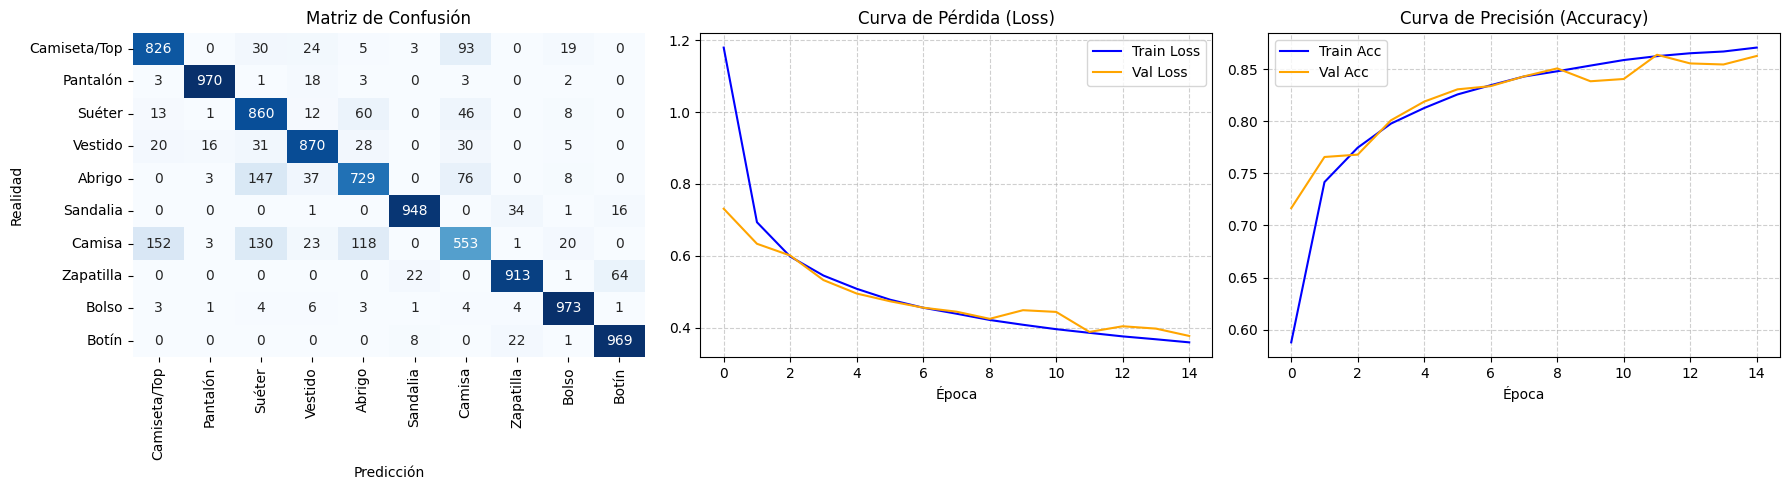

In [13]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import SGD

# 1. ARQUITECTURA A LA VISTA
modelo_1 = models.Sequential()
modelo_1.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
modelo_1.add(layers.MaxPooling2D((2, 2)))
modelo_1.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_1.add(layers.MaxPooling2D((2, 2)))
modelo_1.add(layers.Flatten())
modelo_1.add(layers.Dense(64, activation='relu'))
modelo_1.add(layers.Dense(10, activation='softmax'))

# 2. COMPILACIÓN
modelo_1.compile(optimizer=SGD(learning_rate=0.01),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# 3. ENTRENAMIENTO EXPLÍCITO
print("Iniciando entrenamiento del Modelo 1...")
historia_1 = modelo_1.fit(X_train, Y_train,
                          batch_size=64,
                          epochs=15,
                          validation_split=0.2,
                          verbose=1)

# 4. DELEGAR POST-ENTRENAMIENTO A LA FUNCIÓN
post_entrenamiento(modelo_1, historia_1, X_test, Y_test, nombre_experimento="Modelo_1_SGD")

# Modelo 2: CNN base con optimizador adam

Iniciando entrenamiento del Modelo 2 (Prueba de Velocidad con Adam)...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.8067 - loss: 0.5411 - val_accuracy: 0.8563 - val_loss: 0.3888
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.8735 - loss: 0.3524 - val_accuracy: 0.8717 - val_loss: 0.3543
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.8876 - loss: 0.3068 - val_accuracy: 0.8860 - val_loss: 0.3133
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.8999 - loss: 0.2757 - val_accuracy: 0.8997 - val_loss: 0.2784
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9074 - loss: 0.2526 - val_accuracy: 0.8960 - val_loss: 0.2842
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.9153 - loss: 0.2311 - val_accuracy: 0.9048 - val_loss: 0.2631
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.9215 - loss: 0.2125 - val_accuracy: 0.8956 - val_loss: 0.2827
Epoch 8/15
750/750 

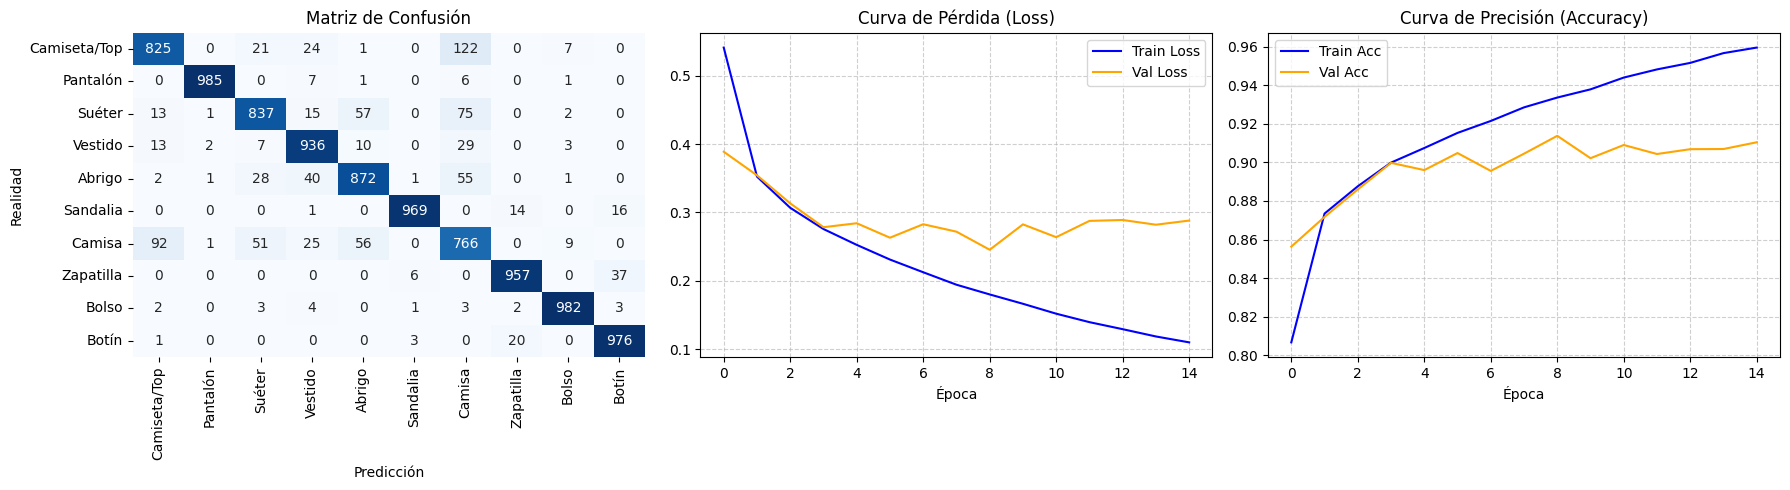

In [17]:
from tensorflow.keras.optimizers import Adam

# 1. ARQUITECTURA (Idéntica al Modelo 1 para aislar la variable)
modelo_2 = models.Sequential()
modelo_2.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
modelo_2.add(layers.MaxPooling2D((2, 2)))
modelo_2.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_2.add(layers.MaxPooling2D((2, 2)))
modelo_2.add(layers.Flatten())
modelo_2.add(layers.Dense(64, activation='relu'))
modelo_2.add(layers.Dense(10, activation='softmax'))

# 2. COMPILACIÓN
modelo_2.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# 3. ENTRENAMIENTO EXPLÍCITO (Mismas 15 épocas)
print("Iniciando entrenamiento del Modelo 2 (Prueba de Velocidad con Adam)...")
historia_2 = modelo_2.fit(X_train, Y_train,
                          batch_size=64,
                          epochs=15,
                          validation_split=0.2,
                          verbose=1)

# 4. EVALUACIÓN Y GRÁFICOS
post_entrenamiento(modelo_2, historia_2, X_test, Y_test, nombre_experimento="Modelo_2_Adam")

# Modelo 3: CNN optimizador adam con dropout

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando entrenamiento del Modelo 3 (Adam + Dropout)...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 71ms/step - accuracy: 0.7205 - loss: 0.7753 - val_accuracy: 0.8339 - val_loss: 0.4575
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.8082 - loss: 0.5270 - val_accuracy: 0.8599 - val_loss: 0.3822
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.8319 - loss: 0.4652 - val_accuracy: 0.8704 - val_loss: 0.3514
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.8455 - loss: 0.4223 - val_accuracy: 0.8811 - val_loss: 0.3230
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.8580 - loss: 0.3927 - val_accuracy: 0.8898 - val_loss: 0.3033
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.8668 - loss: 0.3683 - val_accuracy: 0.8920 - val_loss: 0.2930
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.8727 - loss: 0.3456 - val_accuracy: 0.8952 - val_loss: 0.2897
Epoch 8/15
750/750 ━━━━━━━━━━━━━━

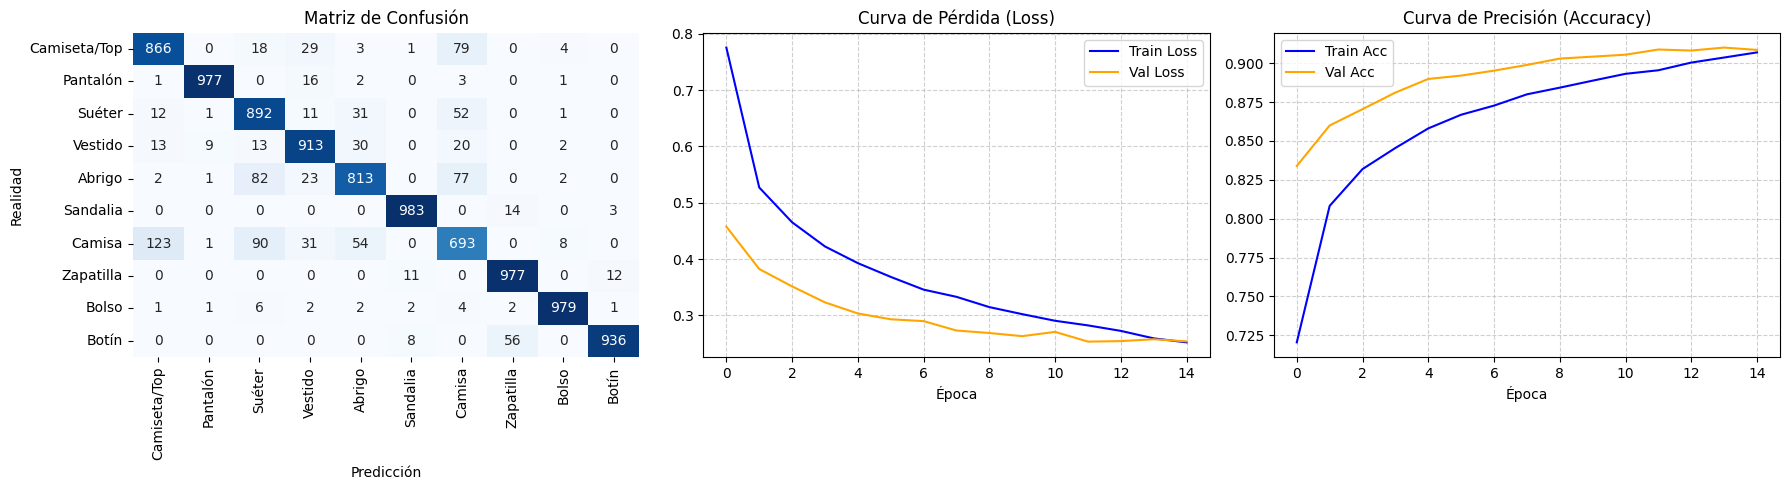

In [18]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models

# 1. ARQUITECTURA CON REGULARIZACIÓN (Dropout)
modelo_3 = models.Sequential()
modelo_3.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
modelo_3.add(layers.MaxPooling2D((2, 2)))
modelo_3.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_3.add(layers.MaxPooling2D((2, 2)))
modelo_3.add(layers.Flatten())
modelo_3.add(layers.Dense(64, activation='relu'))


modelo_3.add(layers.Dropout(0.5))

modelo_3.add(layers.Dense(10, activation='softmax'))

# 2. COMPILACIÓN (Mantenemos Adam para comparar de forma justa)
modelo_3.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# 3. ENTRENAMIENTO EXPLÍCITO
print("Iniciando entrenamiento del Modelo 3 (Adam + Dropout)...")
historia_3 = modelo_3.fit(X_train, Y_train,
                          batch_size=64,
                          epochs=15,
                          validation_split=0.2,
                          verbose=1)

# 4. EVALUACIÓN Y GRÁFICOS
post_entrenamiento(modelo_3, historia_3, X_test, Y_test, nombre_experimento="Modelo_3_Adam_Dropout")

# Modelo 4: padding (adam,dropout,una capa mas de profundidad)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando entrenamiento del Modelo 4 (Profundidad + Padding)...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 95s 123ms/step - accuracy: 0.8036 - loss: 0.5505 - val_accuracy: 0.8717 - val_loss: 0.3538
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 89s 118ms/step - accuracy: 0.8785 - loss: 0.3428 - val_accuracy: 0.8976 - val_loss: 0.2793
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 118ms/step - accuracy: 0.8946 - loss: 0.2913 - val_accuracy: 0.9024 - val_loss: 0.2597
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 88s 117ms/step - accuracy: 0.9079 - loss: 0.2586 - val_accuracy: 0.9045 - val_loss: 0.2548
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 86s 114ms/step - accuracy: 0.9164 - loss: 0.2322 - val_accuracy: 0.9167 - val_loss: 0.2311
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 96s 129ms/step - accuracy: 0.9246 - loss: 0.2081 - val_accuracy: 0.9195 - val_loss: 0.2171
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 88s 117ms/step - accuracy: 0.9304 - loss: 0.1896 - val_accuracy: 0.9206 - val_loss: 0.2238
Epoch 8/15
750/750

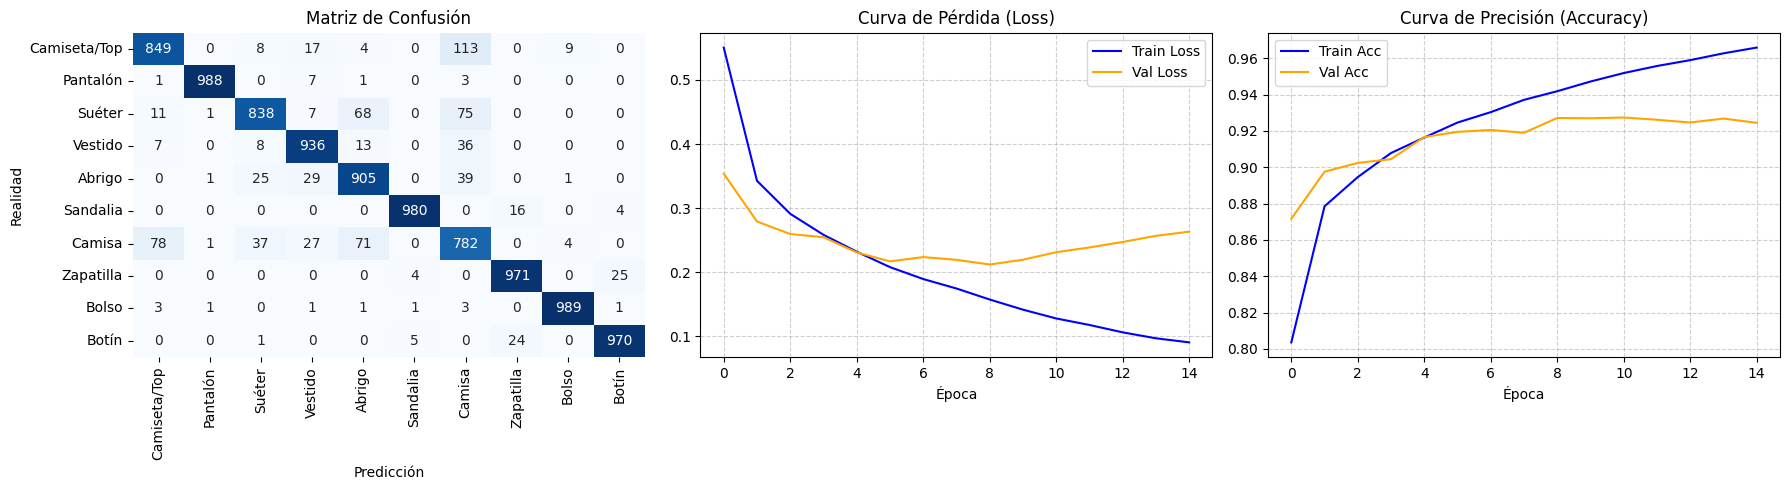

In [19]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models

# 1. ARQUITECTURA PROFUNDA CON PADDING
modelo_4 = models.Sequential()

# Bloque 1
# Agregamos padding='same' para no destruir los bordes de la imagen (mangas)
modelo_4.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)))
modelo_4.add(layers.MaxPooling2D((2, 2)))

# Bloque 2
modelo_4.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
modelo_4.add(layers.MaxPooling2D((2, 2)))

# Bloque 3 (NUEVA CAPA: 128 filtros con padding para extraer texturas finas)
modelo_4.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))

# Clasificador
modelo_4.add(layers.Flatten())
modelo_4.add(layers.Dense(128, activation='relu')) # Subimos a 128 neuronas para la nueva info
modelo_4.add(layers.Dropout(0.5)) # Regularización intacta
modelo_4.add(layers.Dense(10, activation='softmax'))

# 2. COMPILACIÓN
modelo_4.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# 3. ENTRENAMIENTO EXPLÍCITO (Mantenemos la variable de 15 épocas aislada)
print("Iniciando entrenamiento del Modelo 4 (Profundidad + Padding)...")
historia_4 = modelo_4.fit(X_train, Y_train,
                          batch_size=64,
                          epochs=15,
                          validation_split=0.2,
                          verbose=1)

# 4. EVALUACIÓN Y GRÁFICOS
post_entrenamiento(modelo_4, historia_4, X_test, Y_test, nombre_experimento="Modelo_4_Padding")

# Modelo 5: Data augmentation + early stopping

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iniciando entrenamiento del Modelo 5 (Data Augmentation + Early Stopping)...
Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 99s 129ms/step - accuracy: 0.7291 - loss: 0.7402 - val_accuracy: 0.8196 - val_loss: 0.4626
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 122ms/step - accuracy: 0.8148 - loss: 0.5132 - val_accuracy: 0.8350 - val_loss: 0.4326
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 120ms/step - accuracy: 0.8395 - loss: 0.4440 - val_accuracy: 0.8653 - val_loss: 0.3477
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 120ms/step - accuracy: 0.8540 - loss: 0.4005 - val_accuracy: 0.8790 - val_loss: 0.3178
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 89s 119ms/step - accuracy: 0.8645 - loss: 0.3765 - val_accuracy: 0.8913 - val_loss: 0.2896
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 120ms/step - accuracy: 0.8725 - loss: 0.3529 - val_accuracy: 0.8960 - val_loss: 0.2806
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 89s 119ms/step - accuracy: 0.8773 - loss: 0.3354 - val_accuracy: 0.8948 - val_loss: 0.2855
Epoc

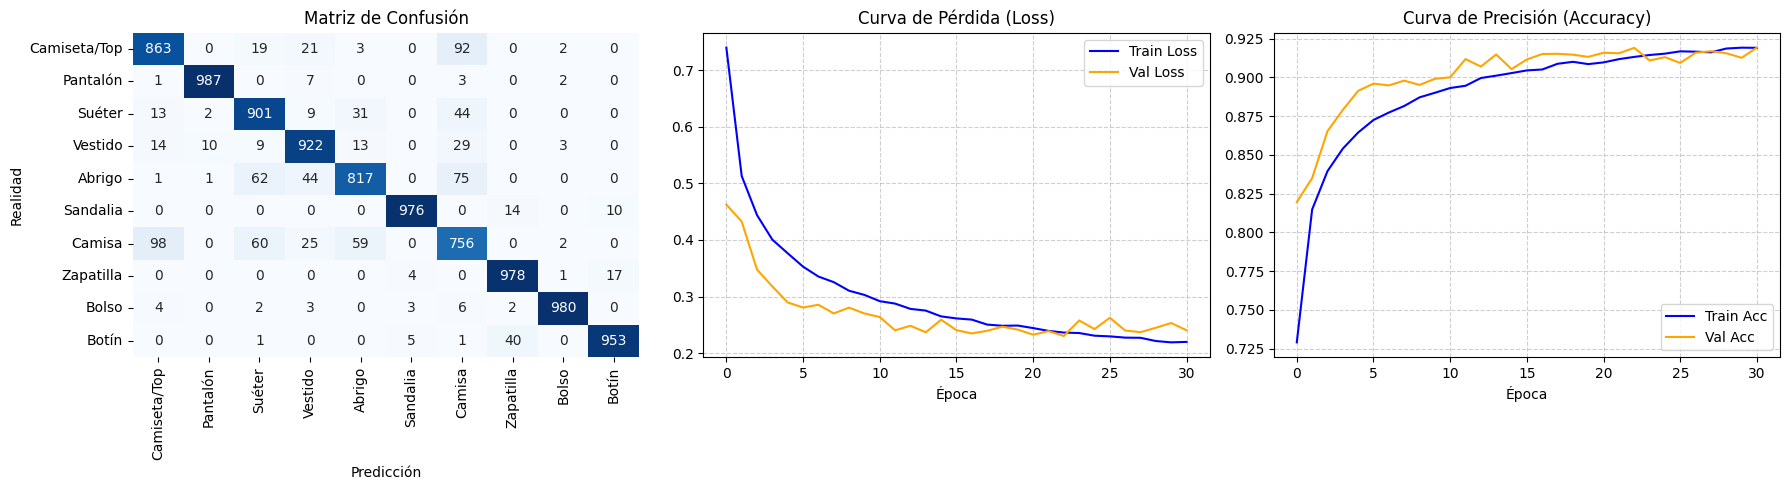

In [20]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 1. ARQUITECTURA (Modelo 4 + Capas de Aumento de Datos)
modelo_5 = models.Sequential()

# --- DATA AUGMENTATION ---
# Actuará como un filtro previo distorsionando las imágenes levemente en cada época
modelo_5.add(layers.RandomFlip("horizontal", input_shape=(28, 28, 1))) # Volteo espejo
modelo_5.add(layers.RandomRotation(0.05))                              # Inclinación de 5%
modelo_5.add(layers.RandomZoom(0.1))                                   # Zoom aleatorio del 10%

# --- EXTRACCIÓN (Idéntica al Modelo 4) ---
# Bloque 1
modelo_5.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
modelo_5.add(layers.MaxPooling2D((2, 2)))

# Bloque 2
modelo_5.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
modelo_5.add(layers.MaxPooling2D((2, 2)))

# Bloque 3
modelo_5.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))

# --- CLASIFICACIÓN (Idéntica al Modelo 4) ---
modelo_5.add(layers.Flatten())
modelo_5.add(layers.Dense(128, activation='relu'))
modelo_5.add(layers.Dropout(0.5))
modelo_5.add(layers.Dense(10, activation='softmax'))

# 2. COMPILACIÓN
modelo_5.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# 3. EL FRENO AUTOMÁTICO
# Como el Data Augmentation hace el aprendizaje más caótico, le damos paciencia de 8 épocas
parada_temprana = EarlyStopping(monitor='val_loss',
                                patience=8,
                                restore_best_weights=True,
                                verbose=1)

# 4. ENTRENAMIENTO EXTENDIDO
print("Iniciando entrenamiento del Modelo 5 (Data Augmentation + Early Stopping)...")
historia_5 = modelo_5.fit(X_train, Y_train,
                          batch_size=64,
                          epochs=50, # Dejamos que el Early Stopping decida el final
                          validation_split=0.2,
                          callbacks=[parada_temprana],
                          verbose=1)

# 5. EVALUACIÓN Y GRÁFICOS
post_entrenamiento(modelo_5, historia_5, X_test, Y_test, nombre_experimento="Modelo_5_DataAug")

# Modelo 6: Strading

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iniciando entrenamiento del Modelo 6 (Data Augmentation + Strides + Early Stopping)...
Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 129s 162ms/step - accuracy: 0.7307 - loss: 0.7359 - val_accuracy: 0.8292 - val_loss: 0.4586
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 135s 153ms/step - accuracy: 0.8173 - loss: 0.4997 - val_accuracy: 0.8488 - val_loss: 0.4015
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 116s 155ms/step - accuracy: 0.8425 - loss: 0.4320 - val_accuracy: 0.8709 - val_loss: 0.3407
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 156ms/step - accuracy: 0.8571 - loss: 0.3903 - val_accuracy: 0.8763 - val_loss: 0.3234
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 150ms/step - accuracy: 0.8696 - loss: 0.3602 - val_accuracy: 0.8848 - val_loss: 0.3052
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 124s 166ms/step - accuracy: 0.8765 - loss: 0.3399 - val_accuracy: 0.8846 - val_loss: 0.3099
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 112s 149ms/step - accuracy: 0.8834 - loss: 0.3226 - val_accuracy: 0.9000 - val_lo

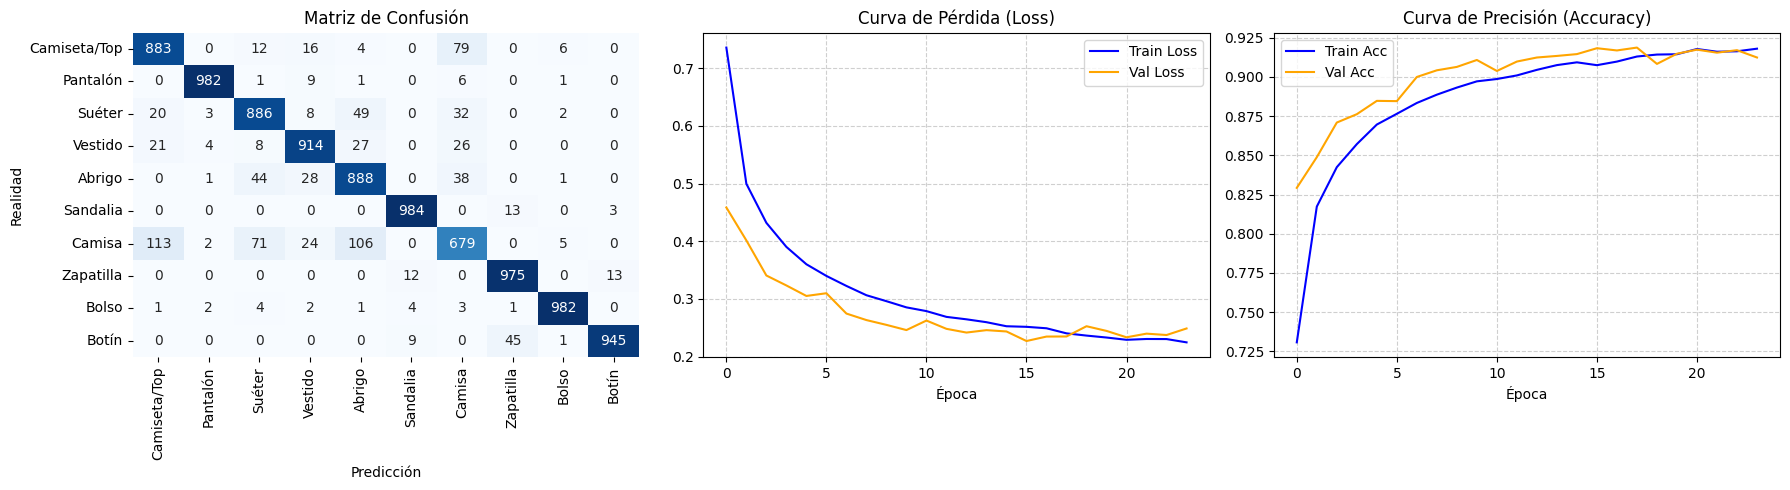

In [21]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 1. LA ARQUITECTURA DEFINITIVA (Data Aug + Strides)
modelo_6 = models.Sequential()

# --- FASE 1: DATA AUGMENTATION ---
modelo_6.add(layers.RandomFlip("horizontal", input_shape=(28, 28, 1)))
modelo_6.add(layers.RandomRotation(0.05))
modelo_6.add(layers.RandomZoom(0.1))

# --- FASE 2: EXTRACCIÓN Y REDUCCIÓN INTELIGENTE ---
# Bloque 1 (Reemplazamos MaxPool por un Conv2D con zancada doble)
modelo_6.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
modelo_6.add(layers.Conv2D(32, (3, 3), strides=(2, 2), padding='same', activation='relu'))

# Bloque 2 (Reemplazamos MaxPool por un Conv2D con zancada doble)
modelo_6.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
modelo_6.add(layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same', activation='relu'))

# Bloque 3 (Nuestra capa profunda para micro-detalles)
modelo_6.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))

# --- FASE 3: CLASIFICACIÓN ---
modelo_6.add(layers.Flatten())
modelo_6.add(layers.Dense(128, activation='relu'))
modelo_6.add(layers.Dropout(0.5))
modelo_6.add(layers.Dense(10, activation='softmax'))

# 2. COMPILACIÓN
modelo_6.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# 3. FRENO AUTOMÁTICO
parada_temprana = EarlyStopping(monitor='val_loss',
                                patience=8,
                                restore_best_weights=True,
                                verbose=1)

# 4. ENTRENAMIENTO DEFINITIVO
print("Iniciando entrenamiento del Modelo 6 (Data Augmentation + Strides + Early Stopping)...")
historia_6 = modelo_6.fit(X_train, Y_train,
                          batch_size=64,
                          epochs=50,
                          validation_split=0.2,
                          callbacks=[parada_temprana],
                          verbose=1)

# 5. EVALUACIÓN Y GRÁFICOS
post_entrenamiento(modelo_6, historia_6, X_test, Y_test, nombre_experimento="Modelo_6_strading")

#Septimo modelo early stop

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()


mi_optimizador = Adam(learning_rate=0.0005)

# 3. Compilación
red.compile(
    loss='categorical_crossentropy',
    optimizer=mi_optimizador,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

En este séptimo experimento se aplicara una una tecnica de regularización más eficientes para combatir el sobreajuste que se identifico en los experimentos previos, el Early Stopping. Se mantendra la arquitectura base y la configuración del optimizador al modelo anterior para asegurar la validez de la comparativa, el objetivo aqui es detener el entrenamiento en el momento exacto antes de que el modelo comience a memorizar el ruido de los datos.

Se conservan los mismos parámetros totales y la estructura de tres capas ocultas con Batch Normalization y Dropout,ademas se manteien el learning_rate = 0.0005 en el optimizador suavizando las curvas de aprendizaje algo que servira para la tecnica de Early Stopping y detectar con mas precision el punto de inflexion en el rendimiento del modelo. Tambien nos facilitara evaluar y verificar el efecto de la detención temprana al ser la unica variable influyente en el cambio de rendimiento permitiendo la comparacion con el modelo anterior.

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=35,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp7_early_stop.keras')

Epoch 1/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - accuracy: 0.8101 - loss: 0.5310 - val_accuracy: 0.8306 - val_loss: 0.4653
Epoch 2/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.8489 - loss: 0.4114 - val_accuracy: 0.8522 - val_loss: 0.4065
Epoch 3/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.8582 - loss: 0.3835 - val_accuracy: 0.8558 - val_loss: 0.3846
Epoch 4/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.8670 - loss: 0.3591 - val_accuracy: 0.8511 - val_loss: 0.3990
Epoch 5/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8714 - loss: 0.3469 - val_accuracy: 0.8709 - val_loss: 0.3522
Epoch 6/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8775 - loss: 0.3293 - val_accuracy: 0.8690 - val_loss: 0.3726
Epoch 7/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8817 - loss: 0.3190 - val_accuracy: 0.8625 - val_loss: 0.3718
Epoch 8/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8835 - loss: 0.3127 - 

En este bloque se ejecuta el entrenamiento del septimo experimento, el cual recibe un cambio notable en la gestión de las epocas. A diferencia de los modelos anteriores que se ejecutaban con 150 epocas, en este caso se ha reducido el limite a 35 epocas.

Al observar los experimentos 3, 4, 5 y 6 que la perdida de validación comenzaba a degradarse (subir) despues y entre las epocas 30-40, el uso de 35 epocas actua como una detención temprana manual. Esto evita que el modelo entre en la zona de sobreajuste critico observada antes.

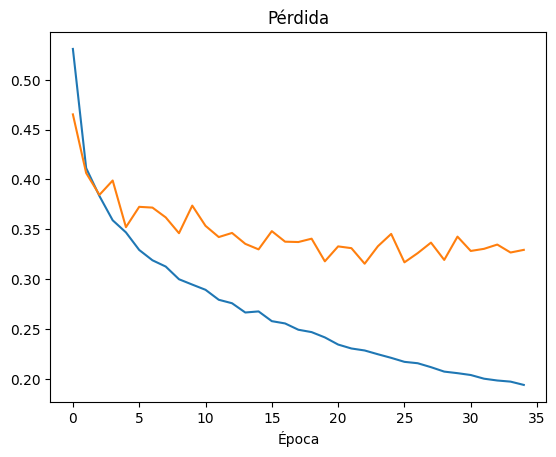

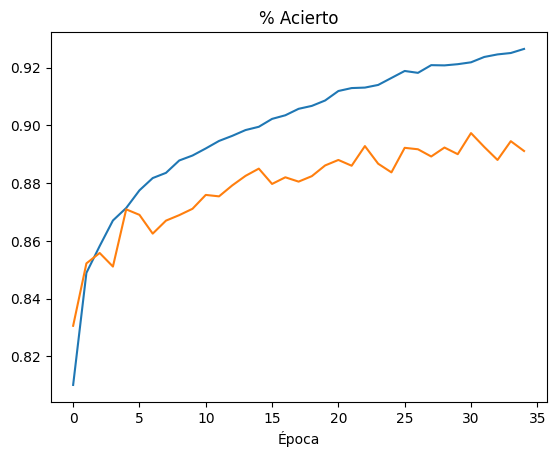

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

En la grafica de Perdida, la curva de validacion se mantiene en un rango mucho mas cercano a la de entrenamiento. Al cortar el proceso en la epoca 35, se evita que la generalizacion comience su ascenso agresivo, capturando el modelo justo antes de que el sobreajuste se vuelva evidente.

La gráfica de Accuracy muestra que la precisión en validación se estabiliza por encima del 88%. Aunque sigue existiendo una brecha respecto al entrenamiento, las oscilaciones son mucho menores que experimentos anteriores, lo que indica que el learning rate de 0.0005 y el menor numero de epocas logro una mayor eficiencia y precision.

ademas podemos decir que alrededor de la epoca 30, el rendimiento en validacion empieza a mostrar signos de estancamiento. Esto afirma que extender el entrenamiento a 150 epocas, como se hizo anteriormente, hacia que el modelo o la red memorizara ruido sin aportar valor real a la clasificación de nuevas imagenes.

Y podemos concluir que, Este modelo es tecnicamente mas robusto porque logra casi la misma eficacia que anteriores modelos, y reduciendo el sobreajuste o ruidos.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.82      0.88      0.85      1000
    Pantalón       0.99      0.98      0.98      1000
      Suéter       0.84      0.78      0.81      1000
     Vestido       0.88      0.90      0.89      1000
      Abrigo       0.75      0.88      0.81      1000
    Sandalia       0.99      0.95      0.97      1000
      Camisa       0.77      0.64      0.70      1000
   Zapatilla       0.93      0.98      0.96      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



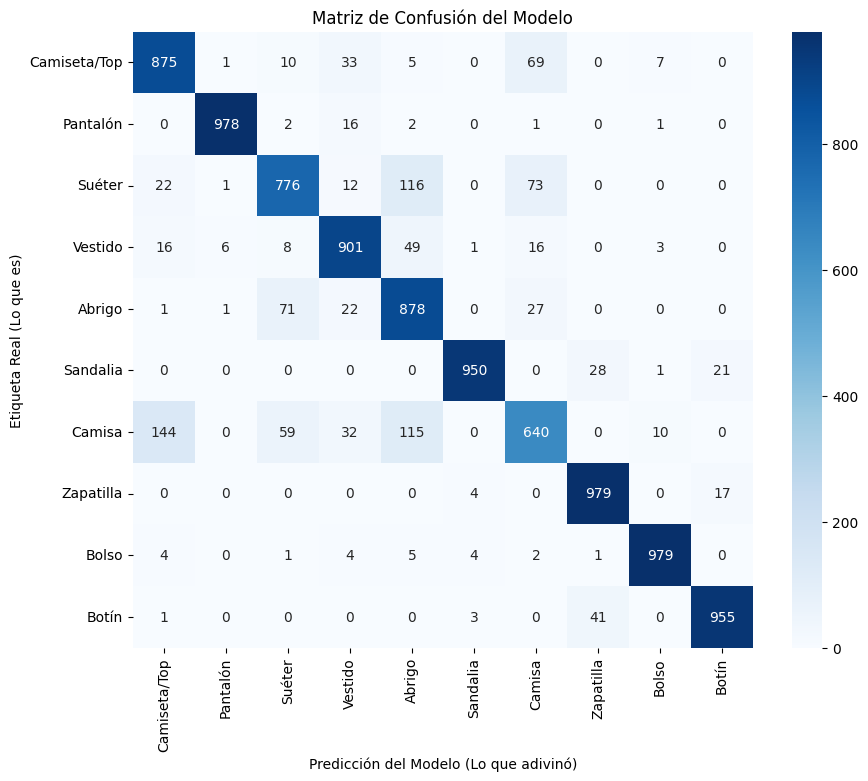

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

El modelo alcanza una precision general del 89%. Esto demuestra que entrenar solo 35 epocas llega hacer suficiente para igualar el rendimiento de modelos que corrieron durante 150 epocas, permitiendo optimizar los recursos de computo.

La categoría Camisa presenta un recall de 0.64 y un F1-score de 0.70. Por otro lado la matriz de confusión revela que la red aun confunde frecuentemente las camisas con Camiseta/Top (144 casos) y Abrigo (115 casos). Al no permitir que el modelo se sobreajuste, los errores se concentran en las similitudes de las prendas.

Esta especie de equilibrio entre las metricas de precisión y recall sugiere que el modelo ha aprendido patrones abstractos mas relevantes en lugar de memorizar el ruido del set de entrenamiento.

Y podemos concluir que, este septimo experimento valida que la calidad de la generalización no depende de la cantidad de epocas, sino de capturar el estado optimo de los pesos.

#Modelo 8 cambio de funcion de activacion

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta
red.add(keras.layers.Dense(h1, input_dim=784, activation='sigmoid'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='sigmoid'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='sigmoid'))
red.add(keras.layers.BatchNormalization())

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()


mi_optimizador = Adam(learning_rate=0.0005)

# 3. Compilación
red.compile(
    loss='categorical_crossentropy',
    optimizer=mi_optimizador,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

Este octavo modelo se realiza un cambio en la configuracion del modelo sustituyendo la función de activación ReLU por la sigmoide en todas las capas ocultas. A diferencia de ReLU, la función sigmoide transforma las salidas de cada neurona en un rango de (0, 1). Aunque esto suele ralentizar el aprendizaje debido al problema del desvanecimiento del gradiente, pero en conjunto con Batch Normalization, se buscara ver si el modelo logra una estabilidad superior o una mayor eficiencia en este conjunto de datos.

Se conservan tanto los parametros totales y el optimizador Adam asegurando que cualquier variación en el rendimiento sea solo por el cambio de la funcion de activacion y no al tamaño de la red. Configuración de Entrenamiento: Se mantiene el optimizador Adam con el learning_rate=0.0005 validado en los experimentos 6 y 7, proporcionando un entorno de control justo para comparar si la sigmoide ayuda a mitigar el sobreajuste o si, por el contrario, limita demasiado la capacidad de aprendizaje de la red.

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=35,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp8_sigmoid.keras')

Epoch 1/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.8117 - loss: 0.5286 - val_accuracy: 0.8252 - val_loss: 0.4943
Epoch 2/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8506 - loss: 0.4144 - val_accuracy: 0.8455 - val_loss: 0.4403
Epoch 3/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8637 - loss: 0.3747 - val_accuracy: 0.8547 - val_loss: 0.4145
Epoch 4/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8735 - loss: 0.3488 - val_accuracy: 0.8631 - val_loss: 0.3809
Epoch 5/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.8797 - loss: 0.3298 - val_accuracy: 0.8602 - val_loss: 0.3890
Epoch 6/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8839 - loss: 0.3131 - val_accuracy: 0.8709 - val_loss: 0.3700
Epoch 7/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8886 - loss: 0.2983 - val_accuracy: 0.8697 - val_loss: 0.3587
Epoch 8/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8931 - loss: 0.2870 - 

En este bloque se realiza el entrenamiento para el octavo modelo es el lo que nos permitira observar como la función de activación sigmoide afecta la velocidad y la calidad del aprendizaje en comparación con los modelos anteriores que utilizaron ReLU.

A diferencia de los experimentos previos, el uso de la sigmoide en las tres capas ocultas hace que lograr el minimo de error sea mas lenta. Se busca verificar si la red logra alcanzar niveles de precisión similares al 89% o mayores, en solo 35 epocas.

Dado que la sigmoide es propensa al desvanecimiento del gradiente, atraves de las capas de Bacth Normalization permitira que este entrenamiento sea viable, manteniendo las activaciones en un rango donde los gradientes no se anulen.

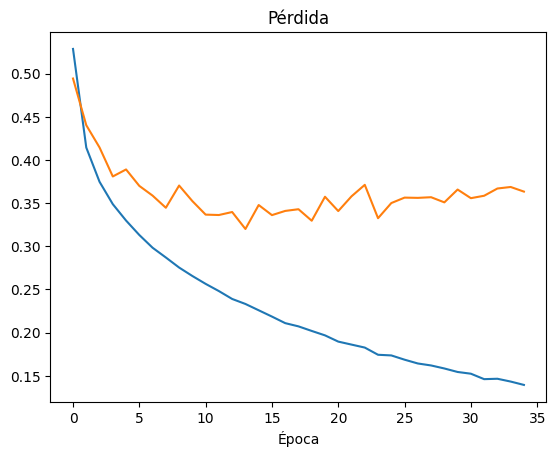

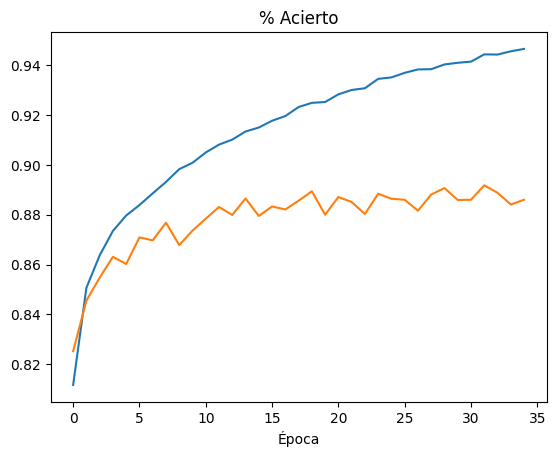

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Las graficas del octavo modelo revela el impacto que tuvo al cambiar la funcion de activacion a sigmoide, mostrando un comportamiento distinto en la forma de aprendizaje respecto a los modelos anteriores basados en ReLU.

En la grafica de Perdida se ve que en la validacion deja de descender significativamente alrededor de la epoca 10, estabilizandose en un nivel superior al de entrenamiento.

A pesar de usar funciones sigmoides, que son mas lentas en el aprendizaje, la brecha entre el entrenamiento y la validacion sigue manteniendose y siendo notable en ambas graficas, y que sigue memorizando el ruido de los datos a pesar de las regularizaciones y cambios hechos.

Es posible notar que aunque el entrenamiento sigue subiendo hacia el 95%, la validacion no logra romper ese limite, lo que indica que el cambio de activacion no necesariamente mejoro la capacidad de generalización frente al modelo anterior, pero tampoco empeoro notablemente.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.83      0.84      0.84      1000
    Pantalón       0.99      0.98      0.98      1000
      Suéter       0.85      0.74      0.79      1000
     Vestido       0.89      0.90      0.89      1000
      Abrigo       0.73      0.89      0.81      1000
    Sandalia       0.98      0.96      0.97      1000
      Camisa       0.73      0.65      0.68      1000
   Zapatilla       0.94      0.97      0.95      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



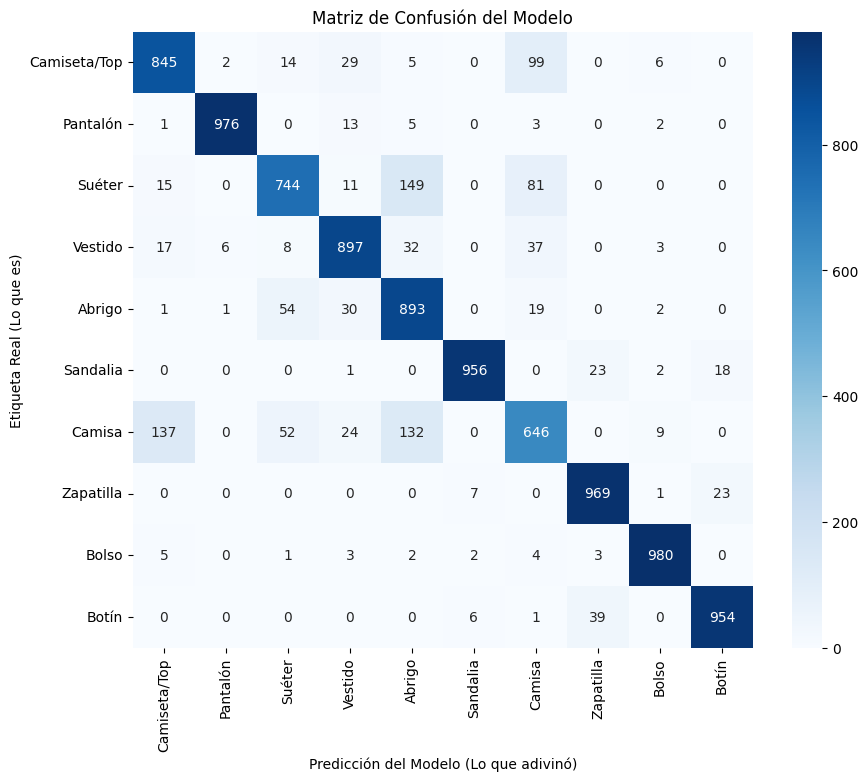

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

El modelo mantiene un 0.89, lo que indica que, a pesar del cambio de funcion de activacion, el rendimiento general es identico al del séptimo modelo bajo las mismas epocas.

La clase Camisa sigue siendo el desafio principal, con un recall de 0.65 y un F1-score de 0.68. Aunque el recall subio un punto respecto al modelo anterior (0.64), la precisión bajo de 0.77 a 0.73, sugiriendo que la sigmoide tiende a ser menos exacta con esta categoría.

Analizando la matriz de confusion el modelo sigue confundiendo las prendas como la Camisa siendo clasificada como Camiseta/Top en 137 ocasiones y como Abrigo en 132 casos.

Y sigue existiendo una confusion significativa entre el Suéter y el Abrigo, lo llegando hacer incluso superior a lo observado en modelos con ReLU aunque esto ultimo suelen ser una diferencia minima.

#modelo 9: numero de capas

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()

mi_optimizador = Adam(learning_rate=0.0005)

# Compilación
red.compile(
    loss='categorical_crossentropy',
    optimizer=mi_optimizador,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 538,890 (2.06 MB)

 Trainable params: 537,354 (2.05 MB)

 Non-trainable params: 1,536 (6.00 KB)

En este noveno experimento, se evaluó el impacto estructural de la red al modificar el hiperparámetro correspondiente al número de capas. Tomando como base la configuración del modelo más estable hasta el momento, se procedió a eliminar la tercera capa oculta, transformando la arquitectura en una red más "superficial" de solo dos capas ocultas.

observaremos si una menor cantidad de parámetros entrenables es capaz de mantener el nivel de generalización reduciendo el esfuerzo de cómputo, o si la pérdida de esa tercera capa disminuye drásticamente la capacidad de la red para extraer características de las prendas.

In [ ]:

hist = red.fit(
    X_train, Y_train,
    epochs=35,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp9_menos_capas.keras')

Epoch 1/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.8099 - loss: 0.5268 - val_accuracy: 0.8226 - val_loss: 0.5035
Epoch 2/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8492 - loss: 0.4135 - val_accuracy: 0.8427 - val_loss: 0.4547
Epoch 3/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8620 - loss: 0.3789 - val_accuracy: 0.8532 - val_loss: 0.4181
Epoch 4/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8687 - loss: 0.3599 - val_accuracy: 0.8537 - val_loss: 0.3972
Epoch 5/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8733 - loss: 0.3459 - val_accuracy: 0.8507 - val_loss: 0.3969
Epoch 6/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8737 - loss: 0.3378 - val_accuracy: 0.8650 - val_loss: 0.3758
Epoch 7/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8799 - loss: 0.3230 - val_accuracy: 0.8717 - val_loss: 0.3540
Epoch 8/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8845 - loss: 0.3135 - 

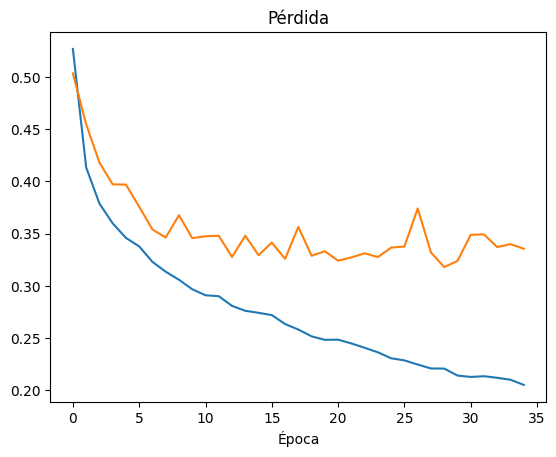

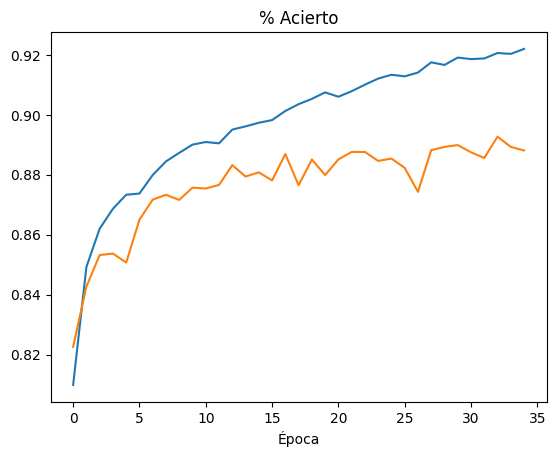

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

Como se puede ver la disminucion de capas no significa una gran perdida de precision del modelo e incluso dando mejores resultados respecto a la metrica de val_loss

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.79      0.89      0.84      1000
    Pantalón       0.99      0.97      0.98      1000
      Suéter       0.82      0.78      0.80      1000
     Vestido       0.93      0.86      0.90      1000
      Abrigo       0.78      0.85      0.82      1000
    Sandalia       0.99      0.95      0.97      1000
      Camisa       0.72      0.65      0.68      1000
   Zapatilla       0.93      0.98      0.95      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.97      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



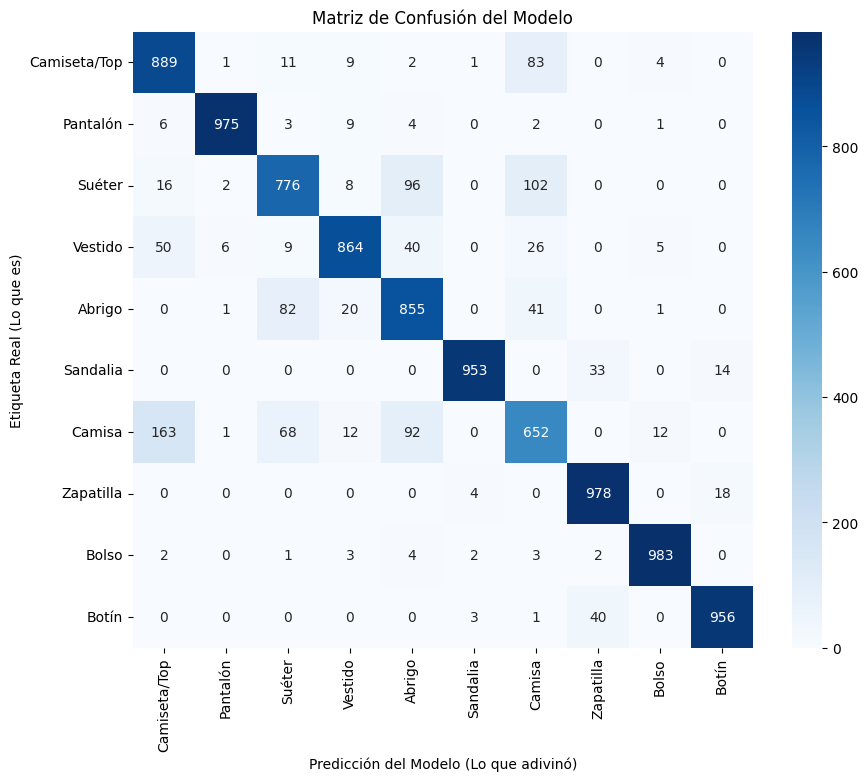

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

Viendo estos resultados podemos concluir que segun el contexto y el problema no siempre es mejor mayor cantidad de capas, si no que incluso puede llegar a ser beneficioso, en este caso esto puede significar que una arquitectura de mayor capas sea demasiado grande y profunda dando la oportunidad al modelo de en vez de aprender, memorizar,dando peores resultados para un dataset como este.

#modelo 10 funcion de error

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
import numpy as np

np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256
C = 10

red = keras.Sequential()

# Primera capa oculta
red.add(keras.layers.Dense(h1, input_dim=784, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.3))

# Segunda capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())
red.add(keras.layers.Dropout(0.2))

# Tercera capa oculta
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.BatchNormalization())

# Capa de salida
red.add(keras.layers.Dense(C, activation='softmax'))

red.summary()


mi_optimizador = Adam(learning_rate=0.0005)

# 3. Compilación
red.compile(
    loss='kl_divergence',
    optimizer=mi_optimizador,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,706 (2.31 MB)

 Trainable params: 603,658 (2.30 MB)

 Non-trainable params: 2,048 (8.00 KB)

Para el Experimento 10, se evaluó el comportamiento de la red utilizando KL Divergence como función de error, en lugar de la Categorical Crossentropy estándar.

la Divergencia KL es una métrica que evalúa qué tan diferente es la suposición de nuestro modelo en comparación con la realidad de los datos.

La Divergencia KL no mide un error lineal tradicional, sino que calcula el "costo" adicional en términos de información. Si el modelo asume que el mundo funciona según una distribución, pero en la realidad funciona según otra distribución, la métrica evalúa cuánta "sorpresa" o ineficiencia genera esa suposición incorrecta.

In [ ]:
hist = red.fit(
    X_train, Y_train,
    epochs=35,
    batch_size=64,
    validation_data=(X_test, Y_test)
)
red.save('modelo_exp10_kl_divergence.keras')

Epoch 1/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.8436 - loss: 0.4321 - val_accuracy: 0.8442 - val_loss: 0.4467
Epoch 2/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8564 - loss: 0.3908 - val_accuracy: 0.8535 - val_loss: 0.4005
Epoch 3/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8643 - loss: 0.3696 - val_accuracy: 0.8425 - val_loss: 0.4510
Epoch 4/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8709 - loss: 0.3540 - val_accuracy: 0.8506 - val_loss: 0.4089
Epoch 5/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.8738 - loss: 0.3386 - val_accuracy: 0.8635 - val_loss: 0.3712
Epoch 6/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8801 - loss: 0.3220 - val_accuracy: 0.8641 - val_loss: 0.3793
Epoch 7/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8820 - loss: 0.3172 - val_accuracy: 0.8703 - val_loss: 0.3540
Epoch 8/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8860 - loss: 0.3054 - 

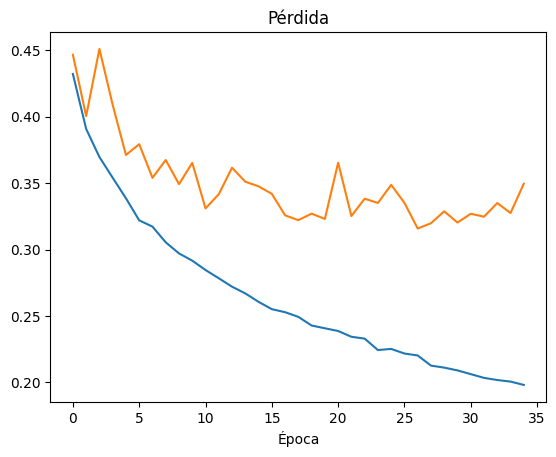

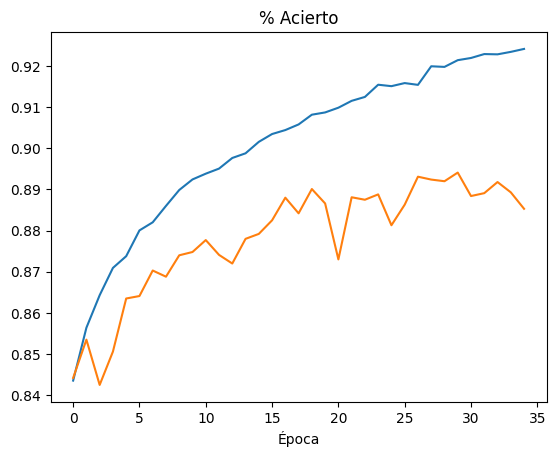

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- CUADRO RESUMEN DE MÉTRICAS ---
              precision    recall  f1-score   support

Camiseta/Top       0.84      0.86      0.85      1000
    Pantalón       0.99      0.98      0.98      1000
      Suéter       0.87      0.74      0.80      1000
     Vestido       0.88      0.92      0.90      1000
      Abrigo       0.74      0.89      0.81      1000
    Sandalia       0.99      0.93      0.96      1000
      Camisa       0.76      0.67      0.71      1000
   Zapatilla       0.88      0.98      0.93      1000
       Bolso       0.97      0.98      0.97      1000
       Botín       0.96      0.91      0.94      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.88     10000
weighted avg       0.89      0.89      0.88     10000



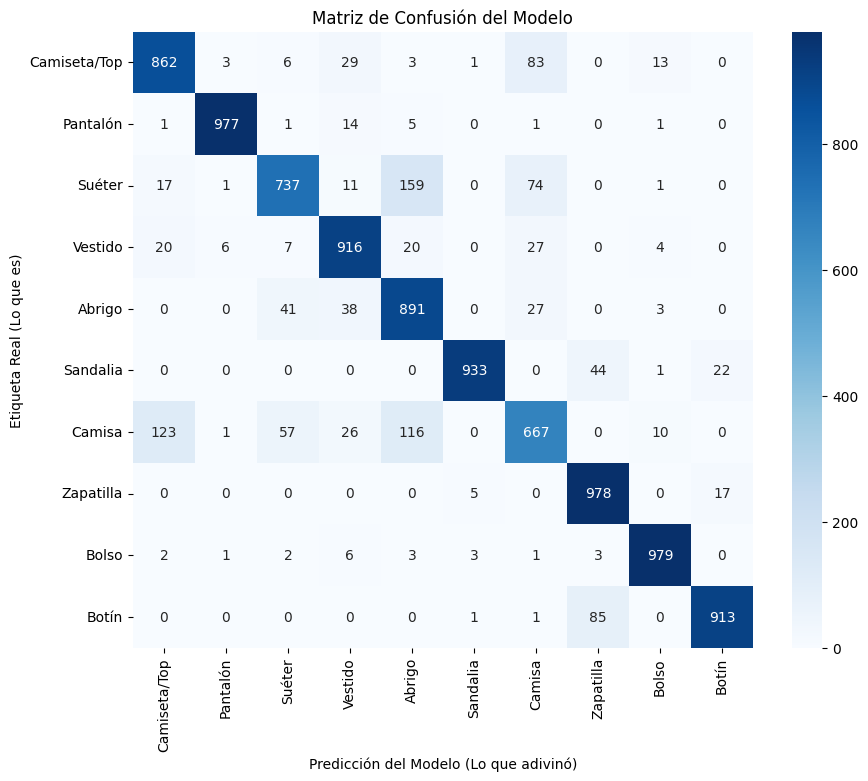

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


predicciones = red.predict(X_test)

y_pred_classes = np.argmax(predicciones, axis=1)

y_true_classes = np.argmax(Y_test, axis=1)


class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


print("--- CUADRO RESUMEN DE MÉTRICAS ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión del Modelo')
plt.ylabel('Etiqueta Real (Lo que es)')
plt.xlabel('Predicción del Modelo (Lo que adivinó)')
plt.show()

El modelo alcanzó una precisión casi idéntico al obtenido con Crossentropy. Esto demuestra que, para un problema de clasificación multiclase como Fashion-MNIST, ambas funciones de error son igual de efectivas para guiar el aprendizaje.



# Tabla comparativa

In [ ]:
import pandas as pd
from IPython.display import display

historial_experimentos = []
historial_experimentos.append({
    'Modelo': 'Exp 1: Base (SGD)',
    'Épocas': 150, 'LR': '0.01 (Defecto)', 'Batch Size': 128,
    'Val Accuracy': '88.0%',
    'Val Loss': '0.42',
    'Observación Principal': 'Convergencia constante pero con evidente overfitting.'
})
historial_experimentos.append({
    'Modelo': 'Exp 2: Dropout (SGD)',
    'Épocas': 150, 'LR': '0.01 (Defecto)', 'Batch Size': 128,
    'Val Accuracy': '89.4%',
    'Val Loss': '0.32',
    'Observación Principal': 'Mejora la generalización; curvas de aprendizaje mucho más estables.'
})
historial_experimentos.append({
    'Modelo': 'Exp 3: Adam',
    'Épocas': 150, 'LR': '0.001 (Defecto)', 'Batch Size': 128,
    'Val Accuracy': '90.3%',
    'Val Loss': '0.40',
    'Observación Principal': 'Aprendizaje más rápido pero genera inestabilidad y sobreajuste agresivo.'
})
historial_experimentos.append({
    'Modelo': 'Exp 4: Batch Normalization',
    'Épocas': 150, 'LR': '0.001 (Defecto)', 'Batch Size': 128,
    'Val Accuracy': '89.3%',
    'Val Loss': '0.44',
    'Observación Principal': 'No logra frenar la inestabilidad de Adam; el overfitting persiste.'
})
historial_experimentos.append({
    'Modelo': 'Exp 5: Batch Size Reducido',
    'Épocas': 150, 'LR': '0.001 (Defecto)', 'Batch Size': 64,
    'Val Accuracy': '89.2%',
    'Val Loss': '0.43',
    'Observación Principal': 'Aprendizaje más profundo en train, pero no soluciona la oscilación en validación.'
})
historial_experimentos.append({
    'Modelo': 'Exp 6: Learning Rate Reducido',
    'Épocas': 150, 'LR': '0.0005', 'Batch Size': 64,
    'Val Accuracy': '89.5%',
    'Val Loss': '0.41',
    'Observación Principal': 'Elimina curvas bruscas. Aprendizaje suave, pero el modelo tiende al overfitting a largo plazo.'
})
historial_experimentos.append({
    'Modelo': 'Exp 7: Early Stopping',
    'Épocas': 35, 'LR': '0.0005', 'Batch Size': 64,
    'Val Accuracy': '89.5%',
    'Val Loss': '0.32',
    'Observación Principal': 'Detención en punto óptimo. Máxima eficiencia mitigando por completo el sobreajuste tardío.'
})
historial_experimentos.append({
    'Modelo': 'Exp 8: Activación Sigmoide',
    'Épocas': 35, 'LR': '0.0005', 'Batch Size': 64,
    'Val Accuracy': '88.9%',
    'Val Loss': '0.36',
    'Observación Principal': 'Aprendizaje más lento y propenso a desvanecimiento del gradiente; menor precisión en clases complejas.'
})
historial_experimentos.append({
    'Modelo': 'Exp 9: disminucion de capas',
    'Épocas': 35, 'LR': '0.0005', 'Batch Size': 64,
    'Val Accuracy': '88,8%',
    'Val Loss': '0.33',
    'Observación Principal': 'Al reducir las capas, el modelo entrenó rápido y mantuvo un accuracy decente (88.8%) con baja pérdida (0.33), demostrando que una red menos profunda también es viable para este problema'
})
historial_experimentos.append({
    'Modelo': 'Exp 10: kl_divergence',
    'Épocas': 35, 'LR': '0.0005', 'Batch Size': 64,
    'Val Accuracy': '89,4%',
    'Val Loss': '0.34',
    'Observación Principal': 'modelo alcanzó un desempeño idéntico al de Categorical Crossentropy'
})

tabla_comparativa = pd.DataFrame(historial_experimentos)
display(tabla_comparativa)

,Modelo,Épocas,LR,Batch Size,Val Accuracy,Val Loss,Observación Principal
0,Exp 1: Base (SGD),150,0.01 (Defecto),128,88.0%,0.42,Convergencia constante pero con evidente overf...
1,Exp 2: Dropout (SGD),150,0.01 (Defecto),128,89.4%,0.32,Mejora la generalización; curvas de aprendizaj...
2,Exp 3: Adam,150,0.001 (Defecto),128,90.3%,0.40,Aprendizaje más rápido pero genera inestabilid...
3,Exp 4: Batch Normalization,150,0.001 (Defecto),128,89.3%,0.44,No logra frenar la inestabilidad de Adam; el o...
4,Exp 5: Batch Size Reducido,150,0.001 (Defecto),64,89.2%,0.43,"Aprendizaje más profundo en train, pero no sol..."
5,Exp 6: Learning Rate Reducido,150,0.0005,64,89.5%,0.41,"Elimina curvas bruscas. Aprendizaje suave, per..."
6,Exp 7: Early Stopping,35,0.0005,64,89.5%,0.32,Detención en punto óptimo. Máxima eficiencia m...
7,Exp 8: Activación Sigmoide,35,0.0005,64,88.9%,0.36,Aprendizaje más lento y propenso a desvanecimi...
8,Exp 9: disminucion de capas,35,0.0005,64,"88,8%",0.33,"Al reducir las capas, el modelo entrenó rápido..."
9,Exp 10: kl_divergence,35,0.0005,64,"89,4%",0.34,modelo alcanzó un desempeño idéntico al de Cat...


#Conclusion

Tras desarrollar y evaluar una serie de experimentos controlados sobre la arquitectura del Perceptrón Multicapa para el dataset Fashion-MNIST, se determina que el Experimento 7 (implementación de Early Stopping) es el modelo mas optimo segun los experimentos llevados a cabo.

Aunque este modelo alcanzó un val_accuracy del 89.5% (ligeramente inferior al pico de 90.3% del modelo con Adam base) es el modelo con la mayor capacidad de generalizacion, ya que no se le da el suficiente tiempo para memorizar como tambien deberia de tener la capacidad de un rapido procesamiento al utilizar pocas epocas.

Como trabajo futuro y propuesta de mejora, el siguiente paso lógico sería transicionar a una arquitectura CNN para conseguir una mayor precision en las las predicciones, especialmente en el apartado de las camisas.



#Demo modelo

Modelo '/content/modelo_exp7_early_stop.keras' cargado exitosamente.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


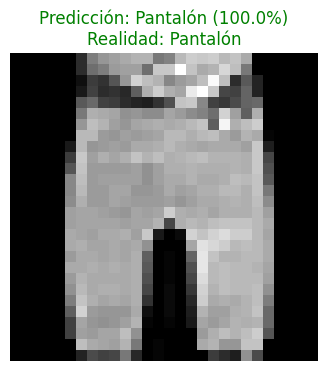

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random


nombres_clases = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
                  'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


nombre_archivo = '/content/modelo_exp7_early_stop.keras'
try:
    modelo_cargado = tf.keras.models.load_model(nombre_archivo)
    print(f"Modelo '{nombre_archivo}' cargado exitosamente.")
except Exception as e:
    print(f"Error al cargar el modelo: {e}")


_, (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()


x_test = x_test / 255.0


indice_random = random.randint(0, len(x_test) - 1)
imagen_demo = x_test[indice_random]
etiqueta_real = y_test[indice_random]


imagen_batch = imagen_demo.reshape(1, 784)

predicciones = modelo_cargado.predict(imagen_batch)


indice_prediccion = np.argmax(predicciones[0])
confianza = np.max(predicciones[0]) * 100


plt.figure(figsize=(4,4))
plt.imshow(imagen_demo, cmap='gray')
plt.axis('off')


color = 'green' if indice_prediccion == etiqueta_real else 'red'

plt.title(f"Predicción: {nombres_clases[indice_prediccion]} ({confianza:.1f}%)\n"
          f"Realidad: {nombres_clases[etiqueta_real]}", color=color)

plt.show()